## 手动特征工程


在第一个notebook中，使用了application数据集构建，为了提高分数，引入更多数据特征

这里，讨论引入`bureau` `bureau balance`

手动特征工程是繁琐的，通常依赖领域知识。
我们尽可能注入更多特征， 由模型识别。
我们会也会使用一些自动化特征工具，
会使用pca等降维

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
plt.style.use('fivethirtyeight')

我们通过一个新 特征：客户过往贷款数量， 来描述meanu feature一般过程

会大量使用pandas操作
- groupby
- agg 对分组计算
- merge 汇总
- rename 列
- 

In [518]:
bureau = pd.read_csv('data/bureau.csv')
train = pd.read_feather('train_base_onehot.feather')
bureau_balance = pd.read_csv('data/bureau_balance.csv')
test = pd.read_feather('test_base_onehot.feather')
print(bureau.shape, train.shape, bureau_balance.shape, test.shape)

(1716428, 17) (307511, 244) (27299925, 3) (48744, 243)


## 新特征

### 示例 bureau 之前贷款数量

In [519]:
bureau_previous_loan_counts = bureau.groupby(by='SK_ID_CURR', as_index= False)['SK_ID_BUREAU'].count().rename(columns = {
    'SK_ID_BUREAU': 'bureau_previous_loan_counts'
})
bureau_previous_loan_counts.sort_values(by='bureau_previous_loan_counts', ascending=False)

,SK_ID_CURR,bureau_previous_loan_counts
17942,120860,116
59911,169704,94
187259,318065,78
130327,251643,61
279405,425396,60
...,...,...
19,100025,1
49,100061,1
39,100048,1
185447,315945,1


In [520]:
train = train.merge(bureau_previous_loan_counts, on='SK_ID_CURR', how='left')

In [521]:
train['bureau_previous_loan_counts'] = train['bureau_previous_loan_counts'].fillna(0)

In [522]:
train['bureau_previous_loan_counts']

0          8.0
1          4.0
2          2.0
3          0.0
4          1.0
          ... 
307506     0.0
307507     0.0
307508     4.0
307509     1.0
307510    11.0
Name: bureau_previous_loan_counts, Length: 307511, dtype: float64

#### Assessing Usefulness of New Variable with r value

In [523]:
train.loc[train['TARGET'] == 0, 'bureau_previous_loan_counts'].sort_values(
    ascending=False
).head()

17891     116.0
60114      94.0
130742     61.0
168939     59.0
25662      58.0
Name: bureau_previous_loan_counts, dtype: float64

Text(0.5, 1.0, 'bureau_previous_loan_counts distribution')

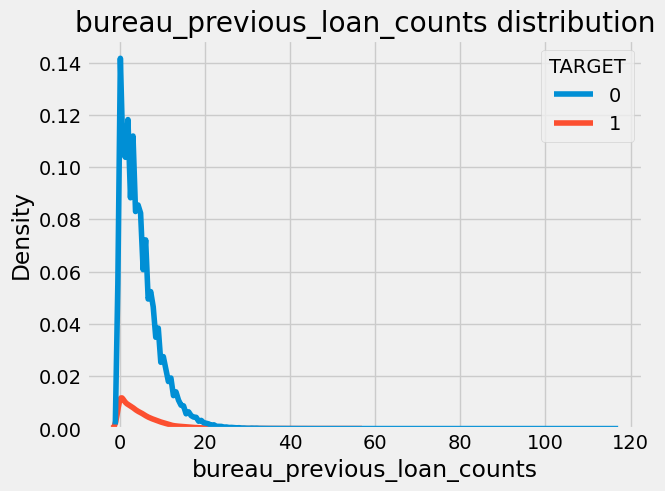

In [524]:
sns.kdeplot(
    data= train,
    x = 'bureau_previous_loan_counts',
    hue = 'TARGET',
)
plt.title('bureau_previous_loan_counts distribution')


几乎是同分布的，没什么区别

In [525]:
corr = np.corrcoef(train['bureau_previous_loan_counts'], train['TARGET'])[0, 1]
print(f'correlations bureau_previous_loan_counts and TARGET is {corr}')

correlations bureau_previous_loan_counts and TARGET is -0.010019715670684074


相关性很低，没有进入之前的top5. 我们没有得到什么信息。

### Agg the numeric volumns

In [526]:
bureau.dtypes

SK_ID_CURR                  int64
SK_ID_BUREAU                int64
CREDIT_ACTIVE                 str
CREDIT_CURRENCY               str
DAYS_CREDIT                 int64
CREDIT_DAY_OVERDUE          int64
DAYS_CREDIT_ENDDATE       float64
DAYS_ENDDATE_FACT         float64
AMT_CREDIT_MAX_OVERDUE    float64
CNT_CREDIT_PROLONG          int64
AMT_CREDIT_SUM            float64
AMT_CREDIT_SUM_DEBT       float64
AMT_CREDIT_SUM_LIMIT      float64
AMT_CREDIT_SUM_OVERDUE    float64
CREDIT_TYPE                   str
DAYS_CREDIT_UPDATE          int64
AMT_ANNUITY               float64
dtype: object

In [527]:
bureau_numeric = bureau.select_dtypes(exclude=['str'])

In [528]:
bureau_agg = bureau_numeric.drop(columns=['SK_ID_BUREAU']).groupby(by='SK_ID_CURR', as_index=False).agg(
    ['min','mean', 'count', 'max', 'sum']
)
bureau_agg

SK_ID_CURR DAYS_CREDIT                                  \
                          min         mean count   max    sum   
0          100001       -1572  -735.000000     7   -49  -5145   
1          100002       -1437  -874.000000     8  -103  -6992   
2          100003       -2586 -1400.750000     4  -606  -5603   
3          100004       -1326  -867.000000     2  -408  -1734   
4          100005        -373  -190.666667     3   -62   -572   
...           ...         ...          ...   ...   ...    ...   
305806     456249       -2713 -1667.076923    13  -483 -21672   
305807     456250       -1002  -862.000000     3  -760  -2586   
305808     456253        -919  -867.500000     4  -713  -3470   
305809     456254       -1104 -1104.000000     1 -1104  -1104   
305810     456255       -2337 -1089.454545    11  -363 -11984   

       CREDIT_DAY_OVERDUE                 ... DAYS_CREDIT_UPDATE               \
                      min mean count max  ...                min         mean   
0                       0  0.0     7   0  ...               -155   -93.142857   
1                       0  0.0     8   0  ...              -1185  -499.875000   
2                       0  0.0     4   0  ...              -2131  -816.000000   
3                       0  0.0     2   0  ...               -682  -532.000000   
4                       0  0.0     3   0  ...               -121   -54.333333   
...                   ...  ...   ...  ..  ...                ...          ...   
305806                  0  0.0    13   0  ...              -2498 -1064.538462   
305807                  0  0.0     3   0  ...               -127   -60.333333   
305808                  0  0.0     4   0  ...               -701  -253.250000   
305809                  0  0.0     1   0  ...               -401  -401.000000   
305810                  0  0.0    11   0  ...              -1621  -531.090909   

                         AMT_ANNUITY                                 \
       count  max    sum         min           mean count       max   
0          7   -6   -652       0.000    3545.357143     7   10822.5   
1          8   -7  -3999       0.000       0.000000     7       0.0   
2          4  -43  -3264         NaN            NaN     0       NaN   
3          2 -382  -1064         NaN            NaN     0       NaN   
4          3  -11   -163       0.000    1420.500000     3    4261.5   
...      ...  ...    ...         ...            ...   ...       ...   
305806    13  -12 -13839         NaN            NaN     0       NaN   
305807     3  -23   -181   27757.395  154567.965000     3  384147.0   
305808     4   -5  -1013   58369.500   58369.500000     3   58369.5   
305809     1 -401   -401       0.000       0.000000     1       0.0   
305810    11   -8  -5842       0.000    1081.500000     9    3244.5   

                    
               sum  
0        24817.500  
1            0.000  
2            0.000  
3            0.000  
4         4261.500  
...            ...  
305806       0.000  
305807  463703.895  
305808  175108.500  
305809       0.000  
305810    9733.500  

[305811 rows x 61 columns]

我们把多层索引平铺

In [529]:
bureau_agg.columns = [
    f"bureau_{col[0]}_{col[1]}" if col[1] != "" else col[0] 
    for col in bureau_agg.columns.values
]
bureau_agg

,SK_ID_CURR,bureau_DAYS_CREDIT_min,bureau_DAYS_CREDIT_mean,bureau_DAYS_CREDIT_count,bureau_DAYS_CREDIT_max,bureau_DAYS_CREDIT_sum,bureau_CREDIT_DAY_OVERDUE_min,bureau_CREDIT_DAY_OVERDUE_mean,bureau_CREDIT_DAY_OVERDUE_count,bureau_CREDIT_DAY_OVERDUE_max,...,bureau_DAYS_CREDIT_UPDATE_min,bureau_DAYS_CREDIT_UPDATE_mean,bureau_DAYS_CREDIT_UPDATE_count,bureau_DAYS_CREDIT_UPDATE_max,bureau_DAYS_CREDIT_UPDATE_sum,bureau_AMT_ANNUITY_min,bureau_AMT_ANNUITY_mean,bureau_AMT_ANNUITY_count,bureau_AMT_ANNUITY_max,bureau_AMT_ANNUITY_sum
0,100001,-1572,-735.000000,7,-49,-5145,0,0.0,7,0,...,-155,-93.142857,7,-6,-652,0.000,3545.357143,7,10822.5,24817.500
1,100002,-1437,-874.000000,8,-103,-6992,0,0.0,8,0,...,-1185,-499.875000,8,-7,-3999,0.000,0.000000,7,0.0,0.000
2,100003,-2586,-1400.750000,4,-606,-5603,0,0.0,4,0,...,-2131,-816.000000,4,-43,-3264,NaN,NaN,0,NaN,0.000
3,100004,-1326,-867.000000,2,-408,-1734,0,0.0,2,0,...,-682,-532.000000,2,-382,-1064,NaN,NaN,0,NaN,0.000
4,100005,-373,-190.666667,3,-62,-572,0,0.0,3,0,...,-121,-54.333333,3,-11,-163,0.000,1420.500000,3,4261.5,4261.500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305806,456249,-2713,-1667.076923,13,-483,-21672,0,0.0,13,0,...,-2498,-1064.538462,13,-12,-13839,NaN,NaN,0,NaN,0.000
305807,456250,-1002,-862.000000,3,-760,-2586,0,0.0,3,0,...,-127,-60.333333,3,-23,-181,27757.395,154567.965000,3,384147.0,463703.895
305808,456253,-919,-867.500000,4,-713,-3470,0,0.0,4,0,...,-701,-253.250000,4,-5,-1013,58369.500,58369.500000,3,58369.5,175108.500
305809,456254,-1104,-1104.000000,1,-1104,-1104,0,0.0,1,0,...,-401,-401.000000,1,-401,-401,0.000,0.000000,1,0.0,0.000


将这些新特征数据与train合并

In [531]:
print(train.shape, bureau_agg.shape)

(307511, 245) (305811, 61)


In [532]:
train = train.merge(bureau_agg, on='SK_ID_CURR', how='left')

In [533]:
train.shape


(307511, 305)

计算一下相关性把

In [534]:
new_columns = list(bureau_agg.columns)
new_columns.remove('SK_ID_CURR')
new_columns

['bureau_DAYS_CREDIT_min',
 'bureau_DAYS_CREDIT_mean',
 'bureau_DAYS_CREDIT_count',
 'bureau_DAYS_CREDIT_max',
 'bureau_DAYS_CREDIT_sum',
 'bureau_CREDIT_DAY_OVERDUE_min',
 'bureau_CREDIT_DAY_OVERDUE_mean',
 'bureau_CREDIT_DAY_OVERDUE_count',
 'bureau_CREDIT_DAY_OVERDUE_max',
 'bureau_CREDIT_DAY_OVERDUE_sum',
 'bureau_DAYS_CREDIT_ENDDATE_min',
 'bureau_DAYS_CREDIT_ENDDATE_mean',
 'bureau_DAYS_CREDIT_ENDDATE_count',
 'bureau_DAYS_CREDIT_ENDDATE_max',
 'bureau_DAYS_CREDIT_ENDDATE_sum',
 'bureau_DAYS_ENDDATE_FACT_min',
 'bureau_DAYS_ENDDATE_FACT_mean',
 'bureau_DAYS_ENDDATE_FACT_count',
 'bureau_DAYS_ENDDATE_FACT_max',
 'bureau_DAYS_ENDDATE_FACT_sum',
 'bureau_AMT_CREDIT_MAX_OVERDUE_min',
 'bureau_AMT_CREDIT_MAX_OVERDUE_mean',
 'bureau_AMT_CREDIT_MAX_OVERDUE_count',
 'bureau_AMT_CREDIT_MAX_OVERDUE_max',
 'bureau_AMT_CREDIT_MAX_OVERDUE_sum',
 'bureau_CNT_CREDIT_PROLONG_min',
 'bureau_CNT_CREDIT_PROLONG_mean',
 'bureau_CNT_CREDIT_PROLONG_count',
 'bureau_CNT_CREDIT_PROLONG_max',
 'bureau_CN

In [535]:
corrs = train[new_columns].corrwith(train['TARGET']).sort_values(ascending=False)
corrs.head()

bureau_DAYS_CREDIT_mean           0.089729
bureau_DAYS_CREDIT_min            0.075248
bureau_DAYS_CREDIT_UPDATE_mean    0.068927
bureau_DAYS_ENDDATE_FACT_min      0.055887
bureau_DAYS_CREDIT_ENDDATE_sum    0.053735
dtype: float64

In [536]:
corrs.tail()

bureau_AMT_CREDIT_SUM_LIMIT_mean   -0.011446
bureau_AMT_CREDIT_SUM_sum          -0.014057
bureau_AMT_CREDIT_SUM_max          -0.019737
bureau_AMT_CREDIT_SUM_mean         -0.019957
bureau_DAYS_ENDDATE_FACT_count     -0.030492
dtype: float64

可以看到，我们构造出几个正相关 还不错的特征！！！😍

继续画图看看

<Axes: xlabel='bureau_DAYS_CREDIT_mean', ylabel='Density'>

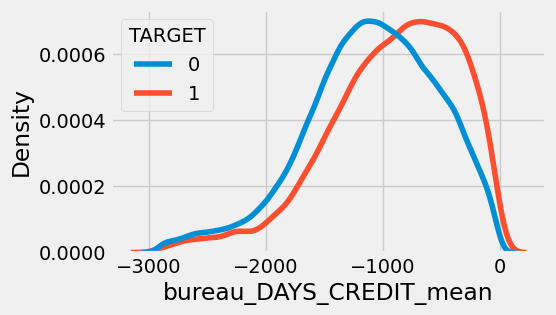

In [537]:
plt.figure(figsize=(5,3))
sns.kdeplot(
    data = train,
    x = 'bureau_DAYS_CREDIT_mean',
    hue = 'TARGET',
    common_norm=False,  # 核心参数：让每一组的曲线下面积都为 1
)

可以看到，分布还是有点区别，那些`DAYS_CREDIT_mean` 平均贷款天数更多的越容易违约

### categorical columns

对于分类变量， 我们可以统计次数

In [538]:
train.shape

(307511, 305)

In [539]:
bureau_categorical = pd.get_dummies(bureau.select_dtypes(include='str'))
bureau_categorical['SK_ID_CURR'] = bureau['SK_ID_CURR']
bureau_categorical

,CREDIT_ACTIVE_Active,CREDIT_ACTIVE_Bad debt,CREDIT_ACTIVE_Closed,CREDIT_ACTIVE_Sold,CREDIT_CURRENCY_currency 1,CREDIT_CURRENCY_currency 2,CREDIT_CURRENCY_currency 3,CREDIT_CURRENCY_currency 4,CREDIT_TYPE_Another type of loan,CREDIT_TYPE_Car loan,...,CREDIT_TYPE_Loan for business development,CREDIT_TYPE_Loan for purchase of shares (margin lending),CREDIT_TYPE_Loan for the purchase of equipment,CREDIT_TYPE_Loan for working capital replenishment,CREDIT_TYPE_Microloan,CREDIT_TYPE_Mobile operator loan,CREDIT_TYPE_Mortgage,CREDIT_TYPE_Real estate loan,CREDIT_TYPE_Unknown type of loan,SK_ID_CURR
0,False,False,True,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,215354
1,True,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,215354
2,True,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,215354
3,True,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,215354
4,True,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,215354
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1716423,True,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,259355
1716424,False,False,True,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,100044
1716425,False,False,True,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,100044
1716426,False,False,True,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,246829


In [540]:
bureau_categorical_agg = bureau_categorical.groupby(by='SK_ID_CURR').agg(
    ['sum', 'mean']
)
bureau_categorical_agg.head()

CREDIT_ACTIVE_Active           CREDIT_ACTIVE_Bad debt       \
                            sum      mean                    sum mean   
SK_ID_CURR                                                              
100001                        3  0.428571                      0  0.0   
100002                        2  0.250000                      0  0.0   
100003                        1  0.250000                      0  0.0   
100004                        0  0.000000                      0  0.0   
100005                        2  0.666667                      0  0.0   

           CREDIT_ACTIVE_Closed           CREDIT_ACTIVE_Sold       \
                            sum      mean                sum mean   
SK_ID_CURR                                                          
100001                        4  0.571429                  0  0.0   
100002                        6  0.750000                  0  0.0   
100003                        3  0.750000                  0  0.0   
100004                        2  1.000000                  0  0.0   
100005                        1  0.333333                  0  0.0   

           CREDIT_CURRENCY_currency 1       ... CREDIT_TYPE_Microloan       \
                                  sum mean  ...                   sum mean   
SK_ID_CURR                                  ...                              
100001                              7  1.0  ...                     0  0.0   
100002                              8  1.0  ...                     0  0.0   
100003                              4  1.0  ...                     0  0.0   
100004                              2  1.0  ...                     0  0.0   
100005                              3  1.0  ...                     0  0.0   

           CREDIT_TYPE_Mobile operator loan      CREDIT_TYPE_Mortgage       \
                                        sum mean                  sum mean   
SK_ID_CURR                                                                   
100001                                    0  0.0                    0  0.0   
100002                                    0  0.0                    0  0.0   
100003                                    0  0.0                    0  0.0   
100004                                    0  0.0                    0  0.0   
100005                                    0  0.0                    0  0.0   

           CREDIT_TYPE_Real estate loan      CREDIT_TYPE_Unknown type of loan  \
                                    sum mean                              sum   
SK_ID_CURR                                                                      
100001                                0  0.0                                0   
100002                                0  0.0                                0   
100003                                0  0.0                                0   
100004                                0  0.0                                0   
100005                                0  0.0                                0   

                 
           mean  
SK_ID_CURR       
100001      0.0  
100002      0.0  
100003      0.0  
100004      0.0  
100005      0.0  

[5 rows x 46 columns]

In [483]:
bureau_categorical_agg.columns[0]

('CREDIT_ACTIVE_Active', 'sum')

In [541]:
bureau_categorical_agg.columns = [ f'bureau_{col[0]}_{col[1]}' for col in bureau_categorical_agg.columns]
bureau_categorical_agg.head()

,bureau_CREDIT_ACTIVE_Active_sum,bureau_CREDIT_ACTIVE_Active_mean,bureau_CREDIT_ACTIVE_Bad debt_sum,bureau_CREDIT_ACTIVE_Bad debt_mean,bureau_CREDIT_ACTIVE_Closed_sum,bureau_CREDIT_ACTIVE_Closed_mean,bureau_CREDIT_ACTIVE_Sold_sum,bureau_CREDIT_ACTIVE_Sold_mean,bureau_CREDIT_CURRENCY_currency 1_sum,bureau_CREDIT_CURRENCY_currency 1_mean,...,bureau_CREDIT_TYPE_Microloan_sum,bureau_CREDIT_TYPE_Microloan_mean,bureau_CREDIT_TYPE_Mobile operator loan_sum,bureau_CREDIT_TYPE_Mobile operator loan_mean,bureau_CREDIT_TYPE_Mortgage_sum,bureau_CREDIT_TYPE_Mortgage_mean,bureau_CREDIT_TYPE_Real estate loan_sum,bureau_CREDIT_TYPE_Real estate loan_mean,bureau_CREDIT_TYPE_Unknown type of loan_sum,bureau_CREDIT_TYPE_Unknown type of loan_mean
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100001,3,0.428571,0,0.0,4,0.571429,0,0.0,7,1.0,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
100002,2,0.250000,0,0.0,6,0.750000,0,0.0,8,1.0,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
100003,1,0.250000,0,0.0,3,0.750000,0,0.0,4,1.0,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
100004,0,0.000000,0,0.0,2,1.000000,0,0.0,2,1.0,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
100005,2,0.666667,0,0.0,1,0.333333,0,0.0,3,1.0,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0


In [542]:
bureau_categorical_agg = bureau_categorical_agg.reset_index()
bureau_categorical_agg.head()

,SK_ID_CURR,bureau_CREDIT_ACTIVE_Active_sum,bureau_CREDIT_ACTIVE_Active_mean,bureau_CREDIT_ACTIVE_Bad debt_sum,bureau_CREDIT_ACTIVE_Bad debt_mean,bureau_CREDIT_ACTIVE_Closed_sum,bureau_CREDIT_ACTIVE_Closed_mean,bureau_CREDIT_ACTIVE_Sold_sum,bureau_CREDIT_ACTIVE_Sold_mean,bureau_CREDIT_CURRENCY_currency 1_sum,...,bureau_CREDIT_TYPE_Microloan_sum,bureau_CREDIT_TYPE_Microloan_mean,bureau_CREDIT_TYPE_Mobile operator loan_sum,bureau_CREDIT_TYPE_Mobile operator loan_mean,bureau_CREDIT_TYPE_Mortgage_sum,bureau_CREDIT_TYPE_Mortgage_mean,bureau_CREDIT_TYPE_Real estate loan_sum,bureau_CREDIT_TYPE_Real estate loan_mean,bureau_CREDIT_TYPE_Unknown type of loan_sum,bureau_CREDIT_TYPE_Unknown type of loan_mean
0,100001,3,0.428571,0,0.0,4,0.571429,0,0.0,7,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
1,100002,2,0.250000,0,0.0,6,0.750000,0,0.0,8,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
2,100003,1,0.250000,0,0.0,3,0.750000,0,0.0,4,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
3,100004,0,0.000000,0,0.0,2,1.000000,0,0.0,2,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
4,100005,2,0.666667,0,0.0,1,0.333333,0,0.0,3,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0


In [543]:
print(train.shape, bureau_categorical_agg.shape)

(307511, 305) (305811, 47)


In [544]:
train = pd.merge(train, bureau_categorical_agg, on='SK_ID_CURR', how='left')

In [545]:
train.shape

(307511, 351)

引入balance中特征

In [546]:
bureau_balance.head()

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


可以统计账单各种状态

In [547]:
bureau_balance_agg = pd.get_dummies(bureau_balance).groupby(by='SK_ID_BUREAU').agg(
    ['sum', 'mean']
)

In [548]:
bureau_balance_agg = bureau_balance_agg.reset_index()
bureau_balance_agg.head()

SK_ID_BUREAU MONTHS_BALANCE       STATUS_0           STATUS_1      STATUS_2  \
                          sum  mean      sum      mean      sum mean      sum   
0      5001709          -4656 -48.0        0  0.000000        0  0.0        0   
1      5001710          -3403 -41.0        5  0.060241        0  0.0        0   
2      5001711             -6  -1.5        3  0.750000        0  0.0        0   
3      5001712           -171  -9.0       10  0.526316        0  0.0        0   
4      5001713           -231 -10.5        0  0.000000        0  0.0        0   

       STATUS_3      STATUS_4      STATUS_5      STATUS_C           STATUS_X  \
  mean      sum mean      sum mean      sum mean      sum      mean      sum   
0  0.0        0  0.0        0  0.0        0  0.0       86  0.886598       11   
1  0.0        0  0.0        0  0.0        0  0.0       48  0.578313       30   
2  0.0        0  0.0        0  0.0        0  0.0        0  0.000000        1   
3  0.0        0  0.0        0  0.0        0  0.0        9  0.473684        0   
4  0.0        0  0.0        0  0.0        0  0.0        0  0.000000       22   

             
       mean  
0  0.113402  
1  0.361446  
2  0.250000  
3  0.000000  
4  1.000000

In [549]:
bureau_balance_agg.columns = [
    f"bureau_{col[0]}_{col[1]}" if col[1] != "" else col[0] 
    for col in bureau_balance_agg.columns.values
]
bureau_balance_agg.head()

,SK_ID_BUREAU,bureau_MONTHS_BALANCE_sum,bureau_MONTHS_BALANCE_mean,bureau_STATUS_0_sum,bureau_STATUS_0_mean,bureau_STATUS_1_sum,bureau_STATUS_1_mean,bureau_STATUS_2_sum,bureau_STATUS_2_mean,bureau_STATUS_3_sum,bureau_STATUS_3_mean,bureau_STATUS_4_sum,bureau_STATUS_4_mean,bureau_STATUS_5_sum,bureau_STATUS_5_mean,bureau_STATUS_C_sum,bureau_STATUS_C_mean,bureau_STATUS_X_sum,bureau_STATUS_X_mean
0,5001709,-4656,-48.0,0,0.000000,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,86,0.886598,11,0.113402
1,5001710,-3403,-41.0,5,0.060241,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,48,0.578313,30,0.361446
2,5001711,-6,-1.5,3,0.750000,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.000000,1,0.250000
3,5001712,-171,-9.0,10,0.526316,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,9,0.473684,0,0.000000
4,5001713,-231,-10.5,0,0.000000,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.000000,22,1.000000


与用户关联


In [550]:
bureau[['SK_ID_CURR', 'SK_ID_BUREAU']]

,SK_ID_CURR,SK_ID_BUREAU
0,215354,5714462
1,215354,5714463
2,215354,5714464
3,215354,5714465
4,215354,5714466
...,...,...
1716423,259355,5057750
1716424,100044,5057754
1716425,100044,5057762
1716426,246829,5057770


In [551]:
bureau_balance_by_client = pd.merge(
    bureau_balance_agg,
    bureau[['SK_ID_CURR', 'SK_ID_BUREAU']], on='SK_ID_BUREAU', how='right'
    )

In [552]:
bureau_balance_by_client

,SK_ID_BUREAU,bureau_MONTHS_BALANCE_sum,bureau_MONTHS_BALANCE_mean,bureau_STATUS_0_sum,bureau_STATUS_0_mean,bureau_STATUS_1_sum,bureau_STATUS_1_mean,bureau_STATUS_2_sum,bureau_STATUS_2_mean,bureau_STATUS_3_sum,bureau_STATUS_3_mean,bureau_STATUS_4_sum,bureau_STATUS_4_mean,bureau_STATUS_5_sum,bureau_STATUS_5_mean,bureau_STATUS_C_sum,bureau_STATUS_C_mean,bureau_STATUS_X_sum,bureau_STATUS_X_mean,SK_ID_CURR
0,5714462,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,215354
1,5714463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,215354
2,5714464,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,215354
3,5714465,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,215354
4,5714466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,215354
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1716423,5057750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,259355
1716424,5057754,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100044
1716425,5057762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100044
1716426,5057770,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,246829


In [554]:
print(train.shape, bureau_balance_by_client.shape)

(307511, 351) (1716428, 20)


In [555]:
train = pd.merge(train, bureau_balance_by_client, on='SK_ID_CURR', how='left')

由于一对多，所以行数增加的

In [556]:
train.shape

(1509345, 370)

## 特征选择
去掉哪些没用的特征

新增的特征集
- bureau_balance_by_client, 
- bureau_categorical_agg
- bureau_previous_loan_counts


### 缺失值

In [557]:
train.shape

(1509345, 370)

In [558]:
def missing_values_table(df):
    """ 统计缺失值
    """
    mis_val = df.isnull().sum()
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    mis_val_table_ren_columns = mis_val_table.rename(columns= {0:'Missing Values', 1:'% of total values'})
    mis_val_table_ren_columns = mis_val_table_ren_columns.sort_values(by='% of total values', ascending = False)
    mis_val_table_ren_columns = mis_val_table_ren_columns.loc[mis_val_table_ren_columns['% of total values'] != 0, :]

    return mis_val_table_ren_columns

In [559]:
missing_train = missing_values_table(train)
missing_train.head(10)

,Missing Values,% of total values
COMMONAREA_MEDI,1029351,68.198523
COMMONAREA_AVG,1029351,68.198523
COMMONAREA_MODE,1029351,68.198523
NONLIVINGAPARTMENTS_AVG,1022525,67.746274
NONLIVINGAPARTMENTS_MODE,1022525,67.746274
NONLIVINGAPARTMENTS_MEDI,1022525,67.746274
bureau_AMT_ANNUITY_max,1018015,67.447469
bureau_AMT_ANNUITY_mean,1018015,67.447469
bureau_AMT_ANNUITY_min,1018015,67.447469
LIVINGAPARTMENTS_MEDI,1005903,66.645002


对于一些缺失过多的字段可以考虑删除掉。比如去掉 超过90%的列

In [560]:
missing_90_columns = missing_train.index[missing_train['% of total values'] > 90]

In [561]:
missing_90_columns

Index([], dtype='str')

test集

In [562]:
test.shape

(48744, 243)

In [563]:
test = pd.merge(test, bureau_balance_by_client, on='SK_ID_CURR', how='left')
test = pd.merge(test, bureau_categorical_agg, on='SK_ID_CURR', how='left')
test = pd.merge(test, bureau_previous_loan_counts, on='SK_ID_CURR', how='left')

In [564]:
test.shape

(257527, 309)

In [565]:
missing_values_table(test)

,Missing Values,% of total values
COMMONAREA_AVG,172130,66.839594
COMMONAREA_MEDI,172130,66.839594
COMMONAREA_MODE,172130,66.839594
NONLIVINGAPARTMENTS_AVG,171209,66.481961
NONLIVINGAPARTMENTS_MODE,171209,66.481961
...,...,...
DEF_30_CNT_SOCIAL_CIRCLE,110,0.042714
OBS_60_CNT_SOCIAL_CIRCLE,110,0.042714
DEF_60_CNT_SOCIAL_CIRCLE,110,0.042714
AMT_ANNUITY,101,0.039219


至此，新特征集已经合并到train,test， 我们可以回收内存

In [566]:
del bureau_balance_by_client, bureau_categorical_agg, bureau_previous_loan_counts
gc.collect()

2904

### 对齐train和test列

In [567]:
train_labels = train['TARGET']
train, test = train.align(test, join='inner', axis=1)
train['TARGET'] = train_labels

In [568]:
train.shape

(1509345, 310)

In [569]:
test.shape

(257527, 309)

对于特征工程的结果，我们保存下

In [570]:
train.to_feather('train_with_bureau_base.feather')
test.to_feather('test_with_bureau_base.feather')

### 对这个特征工程看看相关性， 是不是更好呢？

In [5]:
train = pd.read_feather('train_with_bureau_base.feather')
test = pd.read_feather('test_with_bureau_base.feather')

In [6]:
print(train.shape, test.shape)

(1509345, 310) (257527, 309)


In [7]:
corrs = train.corr()

In [8]:
corrs_sorted = corrs.sort_values(by='TARGET', ascending=False)

In [9]:
corrs_sorted['TARGET'].head(10)

TARGET                                1.000000
bureau_CREDIT_ACTIVE_Active_sum       0.098770
bureau_CREDIT_ACTIVE_Active_mean      0.087464
DAYS_EMPLOYED                         0.070423
bureau_CREDIT_TYPE_Microloan_mean     0.056862
bureau_CREDIT_TYPE_Credit card_sum    0.055881
bureau_MONTHS_BALANCE_sum             0.054817
REGION_RATING_CLIENT_W_CITY           0.051181
REGION_RATING_CLIENT                  0.049232
bureau_MONTHS_BALANCE_mean            0.047249
Name: TARGET, dtype: float64

In [10]:
corrs_sorted['TARGET'].tail(10)

FLOORSMAX_AVG                             -0.038857
bureau_CREDIT_TYPE_Consumer credit_mean   -0.042711
CODE_GENDER_F                             -0.042889
bureau_STATUS_C_sum                       -0.047547
NAME_EDUCATION_TYPE_Higher education      -0.051518
DAYS_BIRTH                                -0.067763
bureau_CREDIT_ACTIVE_Closed_mean          -0.088748
EXT_SOURCE_2                              -0.147898
EXT_SOURCE_1                              -0.152659
EXT_SOURCE_3                              -0.184104
Name: TARGET, dtype: float64

可以看到，我们的一些新特征确实有更好的相关性

<Axes: xlabel='bureau_CREDIT_ACTIVE_Active_sum', ylabel='Density'>

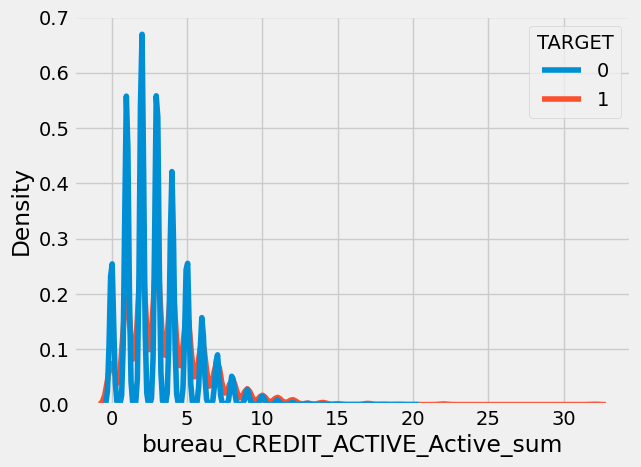

In [11]:
sns.kdeplot(
    data = train,
    x = 'bureau_CREDIT_ACTIVE_Active_sum',
    hue = 'TARGET',
    common_norm = False
)

好吧，目前看来没啥用

此外我们可以剔除一些高度相关变量

In [12]:
corrs.head()

,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,bureau_STATUS_3_mean,bureau_STATUS_4_sum,bureau_STATUS_4_mean,bureau_STATUS_5_sum,bureau_STATUS_5_mean,bureau_STATUS_C_sum,bureau_STATUS_C_mean,bureau_STATUS_X_sum,bureau_STATUS_X_mean,TARGET
SK_ID_CURR,1.000000,-0.001282,-0.000453,-0.001938,-0.000889,-0.001384,0.001429,0.001710,0.003489,0.000687,...,-0.001045,-0.001286,-0.001344,-0.002529,-0.002635,-0.000377,-0.001044,-0.001509,0.002658,-0.002900
CNT_CHILDREN,-0.001282,1.000000,0.014862,0.001348,0.024687,-0.002533,-0.018244,-0.370522,0.080254,0.187848,...,-0.002418,-0.001623,-0.001950,-0.001673,-0.001824,-0.009204,0.001553,-0.005276,-0.001708,0.016816
AMT_INCOME_TOTAL,-0.000453,0.014862,1.000000,0.170890,0.212310,0.173246,0.076127,-0.036491,-0.007214,0.034340,...,-0.007094,-0.005852,-0.004251,-0.001746,0.001224,-0.004278,-0.017613,0.017259,0.012290,-0.000995
AMT_CREDIT,-0.001938,0.001348,0.170890,1.000000,0.775869,0.986754,0.090501,0.033063,-0.066665,0.013786,...,-0.006306,-0.004596,-0.003695,0.000661,0.000104,0.027382,0.010501,0.025858,0.012755,-0.022454
AMT_ANNUITY,-0.000889,0.024687,0.212310,0.775869,1.000000,0.778632,0.110554,-0.028819,-0.028963,0.042749,...,-0.003780,-0.002295,-0.001752,-0.000685,-0.001242,0.036044,0.022520,0.021806,0.003028,-0.007404


In [13]:
corr_abs = corrs.abs()

In [14]:
threshold = 0.8
high_corr = {}
for col in corr_abs:
    high_corr[col] = list(corr_abs.index[(corr_abs[col] > threshold) & (corr_abs[col] != 1)])
high_corr

{'SK_ID_CURR': [],
 'CNT_CHILDREN': ['CNT_FAM_MEMBERS'],
 'AMT_INCOME_TOTAL': [],
 'AMT_CREDIT': ['AMT_GOODS_PRICE'],
 'AMT_ANNUITY': [],
 'AMT_GOODS_PRICE': ['AMT_CREDIT'],
 'REGION_POPULATION_RELATIVE': [],
 'DAYS_BIRTH': [],
 'DAYS_EMPLOYED': [],
 'DAYS_REGISTRATION': [],
 'DAYS_ID_PUBLISH': [],
 'OWN_CAR_AGE': [],
 'FLAG_MOBIL': [],
 'FLAG_EMP_PHONE': ['NAME_INCOME_TYPE_Pensioner',
  'ORGANIZATION_TYPE_XNA',
  'DAYS_EMPLOYED_ANOM'],
 'FLAG_WORK_PHONE': [],
 'FLAG_CONT_MOBILE': [],
 'FLAG_PHONE': [],
 'FLAG_EMAIL': [],
 'CNT_FAM_MEMBERS': ['CNT_CHILDREN'],
 'REGION_RATING_CLIENT': ['REGION_RATING_CLIENT_W_CITY'],
 'REGION_RATING_CLIENT_W_CITY': ['REGION_RATING_CLIENT'],
 'HOUR_APPR_PROCESS_START': [],
 'REG_REGION_NOT_LIVE_REGION': [],
 'REG_REGION_NOT_WORK_REGION': ['LIVE_REGION_NOT_WORK_REGION'],
 'LIVE_REGION_NOT_WORK_REGION': ['REG_REGION_NOT_WORK_REGION'],
 'REG_CITY_NOT_LIVE_CITY': [],
 'REG_CITY_NOT_WORK_CITY': ['LIVE_CITY_NOT_WORK_CITY'],
 'LIVE_CITY_NOT_WORK_CITY': ['REG_CI

对于高度相关的特征对.
- 如果

In [15]:
upper = corr_abs.where(
    np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
    )   
upper

,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,bureau_STATUS_3_mean,bureau_STATUS_4_sum,bureau_STATUS_4_mean,bureau_STATUS_5_sum,bureau_STATUS_5_mean,bureau_STATUS_C_sum,bureau_STATUS_C_mean,bureau_STATUS_X_sum,bureau_STATUS_X_mean,TARGET
SK_ID_CURR,NaN,0.001282,0.000453,0.001938,0.000889,0.001384,0.001429,0.001710,0.003489,0.000687,...,0.001045,0.001286,0.001344,0.002529,0.002635,0.000377,0.001044,0.001509,0.002658,0.002900
CNT_CHILDREN,NaN,NaN,0.014862,0.001348,0.024687,0.002533,0.018244,0.370522,0.080254,0.187848,...,0.002418,0.001623,0.001950,0.001673,0.001824,0.009204,0.001553,0.005276,0.001708,0.016816
AMT_INCOME_TOTAL,NaN,NaN,NaN,0.170890,0.212310,0.173246,0.076127,0.036491,0.007214,0.034340,...,0.007094,0.005852,0.004251,0.001746,0.001224,0.004278,0.017613,0.017259,0.012290,0.000995
AMT_CREDIT,NaN,NaN,NaN,NaN,0.775869,0.986754,0.090501,0.033063,0.066665,0.013786,...,0.006306,0.004596,0.003695,0.000661,0.000104,0.027382,0.010501,0.025858,0.012755,0.022454
AMT_ANNUITY,NaN,NaN,NaN,NaN,NaN,0.778632,0.110554,0.028819,0.028963,0.042749,...,0.003780,0.002295,0.001752,0.000685,0.001242,0.036044,0.022520,0.021806,0.003028,0.007404
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
bureau_STATUS_C_sum,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.802190,0.180113,0.353908,0.047547
bureau_STATUS_C_mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.290708,0.482270,0.037685
bureau_STATUS_X_sum,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.722132,0.020382
bureau_STATUS_X_mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004452


In [16]:
high_corr_pairs = upper.unstack().reset_index()
high_corr_pairs.columns = ['feature_1', 'feature_2', 'corr']
high_corr_pairs = high_corr_pairs[high_corr_pairs['corr'] > threshold]
high_corr_pairs

,feature_1,feature_2,corr
1553,AMT_GOODS_PRICE,AMT_CREDIT,0.986754
5581,CNT_FAM_MEMBERS,CNT_CHILDREN,0.881388
6219,REGION_RATING_CLIENT_W_CITY,REGION_RATING_CLIENT,0.952797
7463,LIVE_REGION_NOT_WORK_REGION,REG_REGION_NOT_WORK_REGION,0.871143
8396,LIVE_CITY_NOT_WORK_CITY,REG_CITY_NOT_WORK_CITY,0.841961
...,...,...,...
86768,bureau_CREDIT_TYPE_Loan for working capital re...,bureau_CREDIT_TYPE_Loan for working capital re...,0.809555
88012,bureau_CREDIT_TYPE_Mobile operator loan_mean,bureau_CREDIT_TYPE_Mobile operator loan_sum,1.000000
89256,bureau_CREDIT_TYPE_Real estate loan_mean,bureau_CREDIT_TYPE_Real estate loan_sum,0.803917
94543,bureau_STATUS_5_mean,bureau_STATUS_5_sum,0.866204


In [17]:
to_drop = set()
missing_counts = train.isnull().sum()
for index, row in high_corr_pairs.iterrows():
    f1, f2 = row['feature_1'], row['feature_2']
    if f1 in to_drop or f2 in to_drop: # 有一个已经在drop了
        continue
    if missing_counts[f1] > missing_counts[f2]:
        to_drop.add(f1)
    else:
        to_drop.add(f2)
to_drop = list(to_drop)
to_drop

['FLAG_EMP_PHONE',
 'LIVINGAPARTMENTS_MEDI',
 'CNT_FAM_MEMBERS',
 'REG_CITY_NOT_WORK_CITY',
 'LIVINGAPARTMENTS_AVG',
 'bureau_STATUS_C_sum',
 'YEARS_BUILD_AVG',
 'NONLIVINGAREA_AVG',
 'NONLIVINGAREA_MODE',
 'bureau_CREDIT_CURRENCY_currency 4_sum',
 'bureau_CREDIT_ACTIVE_Active_mean',
 'bureau_CREDIT_CURRENCY_currency 1_mean',
 'bureau_CREDIT_TYPE_Loan for working capital replenishment_sum',
 'DEF_30_CNT_SOCIAL_CIRCLE',
 'AMT_GOODS_PRICE',
 'bureau_CREDIT_CURRENCY_currency 3_sum',
 'NONLIVINGAPARTMENTS_MODE',
 'LIVINGAREA_MODE',
 'NONLIVINGAPARTMENTS_AVG',
 'FLOORSMIN_AVG',
 'LIVINGAREA_MEDI',
 'FLOORSMAX_AVG',
 'BASEMENTAREA_AVG',
 'ELEVATORS_MODE',
 'COMMONAREA_MODE',
 'bureau_CREDIT_TYPE_Cash loan (non-earmarked)_sum',
 'ORGANIZATION_TYPE_XNA',
 'FLAG_OWN_CAR_N',
 'NAME_TYPE_SUITE_Family',
 'HOUSETYPE_MODE_block of flats',
 'bureau_CREDIT_TYPE_Interbank credit_sum',
 'bureau_CREDIT_TYPE_Mobile operator loan_sum',
 'ELEVATORS_MEDI',
 'bureau_CREDIT_TYPE_Loan for business development_s

从训练集和测试集移除这些列，

In [22]:
len(to_drop)

66

In [23]:
train.columns

Index(['SK_ID_CURR', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE',
       'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
       ...
       'bureau_STATUS_3_mean', 'bureau_STATUS_4_sum', 'bureau_STATUS_4_mean',
       'bureau_STATUS_5_sum', 'bureau_STATUS_5_mean', 'bureau_STATUS_C_sum',
       'bureau_STATUS_C_mean', 'bureau_STATUS_X_sum', 'bureau_STATUS_X_mean',
       'TARGET'],
      dtype='str', length=310)

In [24]:
train_corrs_removed = train.drop(columns=to_drop)
test_corrs_removed = test.drop(columns=to_drop)

In [27]:
train_corrs_removed.to_feather('train_with_bureau_corrs_removed.feather')
test_corrs_removed.to_feather('test_with_bureau_corrs_removed.feather')

In [28]:
del corrs, corr_abs, train_corrs_removed, test_corrs_removed
gc.collect()

70

## modeling

In [29]:
train = pd.read_feather('train_with_bureau_corrs_removed.feather')
test = pd.read_feather('test_with_bureau_corrs_removed.feather')

In [30]:
print(train.shape, test.shape)

(1509345, 244) (257527, 243)
